In [56]:
# STEP 1: Import Libraries 
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [57]:
# STEP 2: Load Dataset 
data = pd.read_csv(r"C:\Users\Samruddhi\OneDrive\Documents\GardGuru\health_dataset_balanced.csv")

In [58]:
data.head()

,Age,BMI,BP,Disease
0,58,18,116,0
1,48,23,130,0
2,34,23,127,0
3,62,33,112,1
4,27,21,151,0


In [59]:
data.info

<bound method DataFrame.info of      Age  BMI   BP  Disease
0     58   18  116        0
1     48   23  130        0
2     34   23  127        0
3     62   33  112        1
4     27   21  151        0
..   ...  ...  ...      ...
995   45   26  123        0
996   53   31  139        1
997   64   30  150        1
998   25   19  113        0
999   56   20  113        0

[1000 rows x 4 columns]>

In [87]:
print(data.isnull().sum())

Age        0
BMI        0
BP         0
Disease    0
dtype: int64


In [60]:
data.describe()

,Age,BMI,BP,Disease
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,44.830000,25.933000,134.120000,0.31700
std,14.346809,4.905158,14.149127,0.46554
min,20.000000,18.000000,110.000000,0.00000
25%,33.000000,22.000000,122.000000,0.00000
50%,45.000000,26.000000,133.500000,0.00000
75%,56.000000,30.000000,146.000000,1.00000
max,69.000000,34.000000,159.000000,1.00000


In [61]:
# STEP 3: Handle Missing Values 
# Replace missing values
data.replace('?', np.nan, inplace=True)

# Fill missing values for all columns
data.fillna(data.mode().iloc[0], inplace=True)

In [62]:
# STEP 4: Encode Categorical Columns 
le = LabelEncoder()

if 'ca' in data.columns:
    data['ca'] = le.fit_transform(data['ca'])

if 'thal' in data.columns:
    data['thal'] = le.fit_transform(data['thal'])

In [63]:
#  STEP 5: Remove Outliers using IQR 
def outlier_remover(df, column):
    Q1 = np.quantile(df[column], 0.25)
    Q3 = np.quantile(df[column], 0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    df[column] = np.clip(df[column], lower_limit, upper_limit)
    return df

# Apply only on feature columns (not target)
for col in data.columns:
    if col != 'Disease':   # or 'target' depending on your dataset
        data = outlier_remover(data, col)

# Convert target column correctly
if 'target' in data.columns:
    data['target'] = data['target'].apply(lambda x: 1 if x > 0 else 0)
elif 'Disease' in data.columns:
    data['Disease'] = data['Disease'].apply(lambda x: 1 if x > 0 else 0)

In [64]:
# STEP 6: Split Data 
if 'target' in data.columns:
    X = data.drop('target', axis=1)
    Y = data['target']
elif 'Disease' in data.columns:
    X = data.drop('Disease', axis=1)
    Y = data['Disease']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


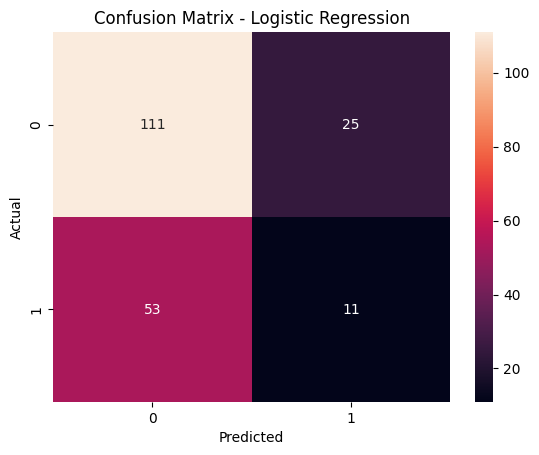

In [65]:
cm = confusion_matrix(Y_test, Y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

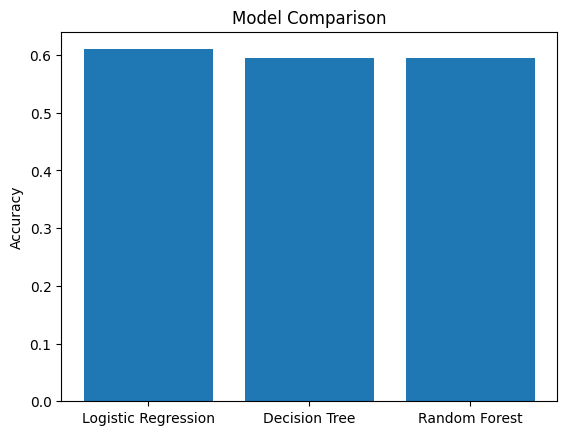

In [66]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracy = [accuracy_score(Y_test, Y_pred_lr),
            accuracy_score(Y_test, Y_pred_dt),
            accuracy_score(Y_test, Y_pred_rf)]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [78]:
# STEP 7: Scale Data 
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)


In [79]:
# Logistic Regression
LR = LogisticRegression()
LR.fit(X_train, Y_train)
Y_pred_lr = LR.predict(X_test)

# Decision Tree
DT = DecisionTreeClassifier(criterion='gini', random_state=42)
DT.fit(X_train, Y_train)
Y_pred_dt = DT.predict(X_test)

# Random Forest
RF = RandomForestClassifier(n_estimators=100, random_state=42)
RF.fit(X_train, Y_train)
Y_pred_rf = RF.predict(X_test)

In [80]:
# STEP 8: Train Models 
# Calculate accuracy
acc_lr = accuracy_score(Y_test, Y_pred_lr)
acc_dt = accuracy_score(Y_test, Y_pred_dt)
acc_rf = accuracy_score(Y_test, Y_pred_rf)

# Store in dictionary
models = {
    "Logistic Regression": acc_lr,
    "Decision Tree": acc_dt,
    "Random Forest": acc_rf
}

# Find best model
best_model = max(models, key=models.get)

# Print result
print("Best Model:", best_model)
print("Best Accuracy:", models[best_model])

Best Model: Decision Tree
Best Accuracy: 1.0


In [81]:
# STEP 9: Evaluate All Models 
models = {
    "Logistic Regression": Y_pred_lr,
    "Decision Tree":       Y_pred_dt,
    "Random Forest":       Y_pred_rf
}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
print("-" * 65)

for name, pred in models.items():
    acc = accuracy_score(Y_test, pred)
    pre = precision_score(Y_test, pred)
    rec = recall_score(Y_test, pred)
    f1  = f1_score(Y_test, pred)
    print(f"{name:<25} {acc:>10.4f} {pre:>10.4f} {rec:>10.4f} {f1:>10.4f}")

Model                       Accuracy  Precision     Recall   F1 Score
-----------------------------------------------------------------
Logistic Regression           0.8800     0.8704     0.7344     0.7966
Decision Tree                 1.0000     1.0000     1.0000     1.0000
Random Forest                 1.0000     1.0000     1.0000     1.0000


In [82]:
#USER INPUT PREDICTION 
# Take input from user
age = float(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
bp = float(input("Enter BP: "))

# Select best model
if best_model == "Logistic Regression":
    model = LR
elif best_model == "Decision Tree":
    model = DT
else:
    model = RF

# Make prediction
prediction = model.predict([[age, bmi, bp]])

# Output result
if prediction[0] == 1:
    print("Person has Disease")
else:
    print("Person is Healthy")


Enter Age:  55
Enter BMI:  28
Enter BP:  130


Person has Disease


In [84]:
age = float(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
bp = float(input("Enter BP: "))

# Select best model
if best_model == "Logistic Regression":
    model = LR
elif best_model == "Decision Tree":
    model = DT
else:
    model = RF
prediction = model.predict([[age, bmi, bp]])

if prediction[0] == 0:
    print("Person has Disease")
else:
    print("Person is Healthy")

Enter Age:  22
Enter BMI:  28
Enter BP:  120


Person is Healthy
